In [1]:
import sys

sys.path.append("..")

In [2]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

from utils.misc import load_config
from datasets.data_preparation import prepare_data
from engine.policy import train
from utils.misc import plot_confusion_matrix, plot_loss_accuracy_curve

In [3]:
exp_path = '../results/policy/dl.vit/2023-08-08 12Hr 53Min 41Sec IST+0530'

config = load_config('.', exp_path, 'hyperparameters.yaml')

In [4]:
trainer_config = config['trainer']
data_config = config['data']

checkpoint_name = trainer_config['checkpoint_name']
device = trainer_config['device']
batch_size = trainer_config['batch_size']

patch_size = data_config['patch']['patch_size']
lithology_classes = data_config['lithology_classes']

config['root'] = '..'

In [5]:
x_train, x_val, y_train, y_val, num_classes = prepare_data(config)

Preparing the data...


Creating Patches: 100%|██████████| 1229/1229 [00:24<00:00, 49.82it/s]


Number of classes: 7 and shape of x_train: torch.Size([2142, 150, 6])


In [6]:
traindataset = TensorDataset(x_train, y_train)
trainloader = DataLoader(traindataset, batch_size=batch_size, shuffle=True)

valdataset = TensorDataset(x_val, y_val)
valloader = DataLoader(valdataset, batch_size=batch_size, shuffle=False)

# invert key as value and value as key
lithology_names = {v: k for k, v in lithology_classes.items()}

In [7]:
# Define the RNN model
# class WellLogRNN(nn.Module):
#     def __init__(self, input_size, hidden_size, num_layers, num_classes):
#         super(WellLogRNN, self).__init__()
#         self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
#         self.fc = nn.Linear(hidden_size, num_classes)
        
#     def forward(self, x):
#         out, _ = self.rnn(x)
#         out = self.fc(out)
#         return out

class WellLogRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, patch_size):
        super(WellLogRNN, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.batch_norm = nn.BatchNorm1d(patch_size)  # Batch normalization layer
        self.activation = nn.ReLU()  # Activation function
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.batch_norm(out)  # Apply batch normalization
        out = self.activation(out)  # Apply activation function
        out = self.fc(out)
        return out

In [8]:
hidden_size = 128
num_layers = 2
model = WellLogRNN(data_config['num_features'], hidden_size, num_layers, num_classes, data_config['patch']['patch_size'])
model = model.to('cuda')

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
(
    train_losses, 
    val_losses, 
    train_accuracies, 
    val_accuracies, 
    best_epoch, 
    best_loss, 
    best_cm_val, 
    best_cm, 
    best_model_chkpt, 
    best_optim_chkpt
) = train(num_epochs=100,
          model=model,
          train_loader=trainloader,
          val_loader=valloader,
          criterion=criterion,
          optimizer=optimizer,
          tolerance=5,
          device=device)

Val - Epoch 1/100: 100%|██████████| 9/9 [00:00<00:00, 160.71it/s]


Epoch 1/100, Train Loss: 1.2783, Train Accuracy:             48.28%, Val Loss: 1.3746, Val Accuracy: 57.98%
Model Performance Improved from epoch no. 1


Val - Epoch 2/100: 100%|██████████| 9/9 [00:00<00:00, 165.56it/s]


Epoch 2/100, Train Loss: 0.9329, Train Accuracy:             60.69%, Val Loss: 0.9549, Val Accuracy: 60.65%
Model Performance Improved from epoch no. 0


Val - Epoch 3/100: 100%|██████████| 9/9 [00:00<00:00, 170.87it/s]


...

Epoch 31/100, Train Loss: 0.6999, Train Accuracy:             69.80%, Val Loss: 0.7272, Val Accuracy: 68.02%


Val - Epoch 32/100: 100%|██████████| 9/9 [00:00<00:00, 173.47it/s]


Epoch 32/100, Train Loss: 0.7112, Train Accuracy:             69.16%, Val Loss: 0.7287, Val Accuracy: 68.27%


Val - Epoch 33/100: 100%|██████████| 9/9 [00:00<00:00, 172.19it/s]

Epoch 33/100, Train Loss: 0.7013, Train Accuracy:             69.68%, Val Loss: 0.7371, Val Accuracy: 67.56%
Early stopping


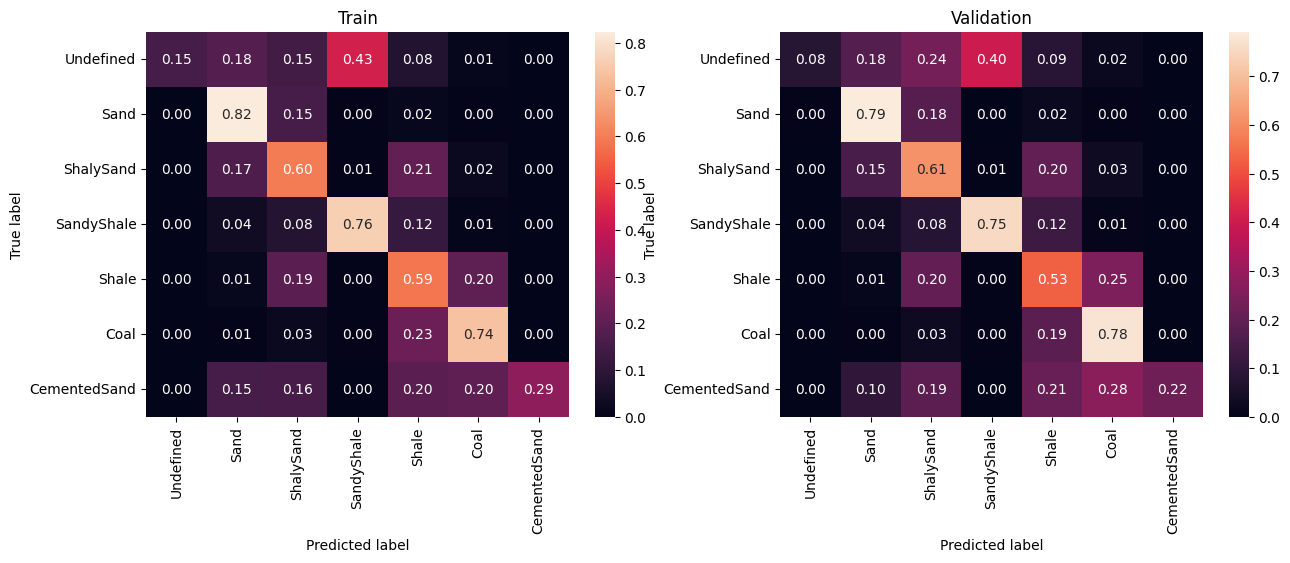

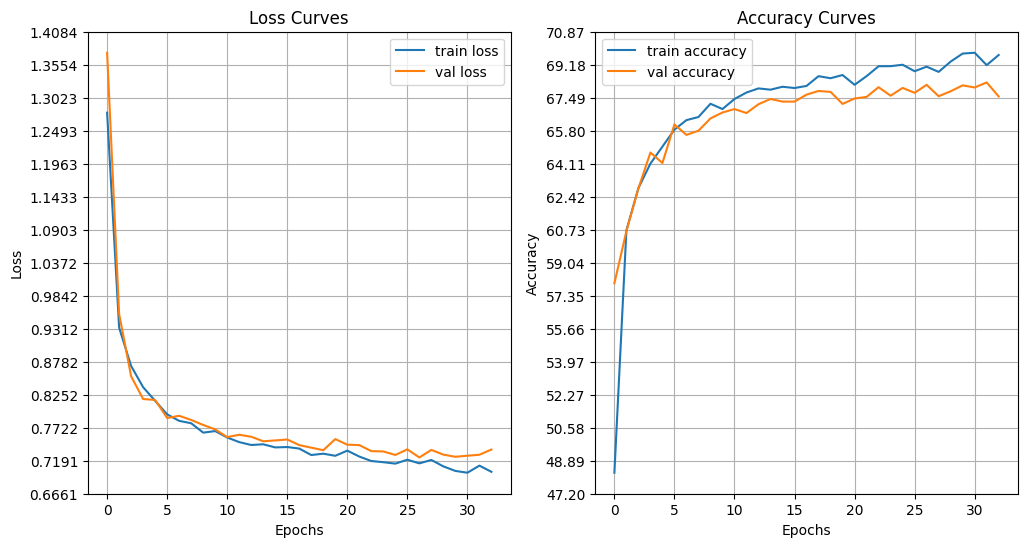

In [12]:
plot_confusion_matrix(best_cm, best_cm_val, lithology_classes, save_path=False)
plot_loss_accuracy_curve(train_losses, val_losses,train_accuracies,val_accuracies,save_path='')